# Ensemble Models

In [ ]:
import pandas as pd
df = pd.read_csv("music_data.csv")

In [ ]:
df.head()

,track_artist,track_album_id,track_album_name,playlist_name,playlist_id,playlist_subgenre,danceability,energy,key,loudness,...,instrumentalness,liveness,valence,tempo,duration_ms,track_id,track_name,track_popularity,release_year,genre
0,Dead Prez,7gXuElmegVReY7imkb5bf8,Let's Get Free,90s Hiphop / Gangsta Rap,5yGuoOwRQF3o8NVRRlvCj7,gangster rap,0.725,0.737,4,-7.453,...,0.00417,0.109,0.219,77.161,214067,2HoDr1yVksl19omOhc1zWy,Hip-Hop,57,2000,Hip-Hop
1,Naughty By Nature,4OEP9VlZWOCt1QcOzX0oXF,19 Naughty III,90's Hip Hop Ultimate Collection,4IG024zoaGMurhTFBkMAv9,southern hip hop,0.862,0.642,6,-13.652,...,0.00000,0.272,0.765,99.201,267267,1SyQ6t9RdRBK0QUCS6a797,Hip Hop Hooray,66,1993,Hip-Hop
2,Naughty By Nature,6smksVgwxaPFGdSsIloCjo,Anthem Inc.,"Back in the day - R&B, New Jack Swing, Swingbe...",3a9y4eeCJRmG9p4YKfqYIx,new jack swing,0.776,0.968,4,-4.250,...,0.00000,0.204,0.667,97.765,250173,1SyQ6t9RdRBK0QUCS6a797,Hip Hop Hooray,66,1993,Hip-Hop
3,Chamillionaire,31dzB4ULKZfOH71tuaBiR8,The Sound of Revenge,Dr. Q's Prescription Playlist💊,6jAPdgY9XmxC9cgkXAVmVv,post-teen pop,0.788,0.798,8,-4.680,...,0.00000,0.300,0.836,143.051,303053,0VUpkue1T9WZF2LtUqJbDY,Hip Hop Police - Main,35,2007,Hip-Hop
4,Chamillionaire,31dzB4ULKZfOH71tuaBiR8,The Sound of Revenge,90s-2000s Southern Hip Hop / Crunk,5wsWBmQgDtKa8CEg7wTEMi,southern hip hop,0.788,0.798,8,-4.680,...,0.00000,0.300,0.836,143.051,303053,0VUpkue1T9WZF2LtUqJbDY,Hip Hop Police - Main,35,2007,Hip-Hop


In [ ]:
df.columns

Index(['track_artist', 'track_album_id', 'track_album_name', 'playlist_name',
       'playlist_id', 'playlist_subgenre', 'danceability', 'energy', 'key',
       'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness',
       'liveness', 'valence', 'tempo', 'duration_ms', 'track_id', 'track_name',
       'track_popularity', 'release_year', 'genre'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6484 entries, 0 to 6483
Data columns (total 23 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   track_artist       6484 non-null   object 
 1   track_album_id     6484 non-null   object 
 2   track_album_name   6484 non-null   object 
 3   playlist_name      6484 non-null   object 
 4   playlist_id        6484 non-null   object 
 5   playlist_subgenre  6484 non-null   object 
 6   danceability       6484 non-null   float64
 7   energy             6484 non-null   float64
 8   key                6484 non-null   int64  
 9   loudness           6484 non-null   float64
 10  mode               6484 non-null   int64  
 11  speechiness        6484 non-null   float64
 12  acousticness       6484 non-null   float64
 13  instrumentalness   6484 non-null   float64
 14  liveness           6484 non-null   float64
 15  valence            6484 non-null   float64
 16  tempo              6484 

In [ ]:
# Remove duplicates
df = df.drop_duplicates()
df.size

149132

In [ ]:
df.isnull().sum()

,0
track_artist,0
track_album_id,0
track_album_name,0
playlist_name,0
playlist_id,0
playlist_subgenre,0
danceability,0
energy,0
key,0
loudness,0


In [ ]:
# Fill missing numeric values with median

df.fillna(df.median(numeric_only=True), inplace=True)

In [ ]:
df.describe()

,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,track_popularity,release_year
count,6484.000000,6484.000000,6484.000000,6484.000000,6484.000000,6484.000000,6484.000000,6484.000000,6484.000000,6484.000000,6484.000000,6484.00000,6484.000000,6484.000000
mean,0.656687,0.662695,5.108112,-6.339298,0.541487,0.116708,0.175291,0.028306,0.189283,0.461480,121.143942,225103.89343,60.130475,2013.432603
std,0.152863,0.175067,3.640679,2.571509,0.498314,0.108356,0.218181,0.122330,0.146737,0.220573,28.065763,54901.41406,18.761127,13.324169
min,0.135000,0.045500,0.000000,-23.459000,0.000000,0.023200,0.000015,0.000000,0.009360,0.034900,48.718000,37640.00000,0.000000,1958.000000
25%,0.555000,0.538000,1.000000,-7.621000,0.000000,0.043800,0.018900,0.000000,0.096900,0.293000,99.252000,191661.00000,53.000000,2012.000000
50%,0.671000,0.672000,5.000000,-5.884000,1.000000,0.065300,0.080450,0.000002,0.130000,0.440000,120.073000,216245.00000,63.000000,2018.000000
75%,0.771000,0.799000,8.000000,-4.559000,1.000000,0.153000,0.243000,0.000287,0.237000,0.619000,136.245000,248403.25000,72.000000,2022.000000
max,0.977000,0.998000,11.000000,-0.475000,1.000000,0.918000,0.984000,0.963000,0.984000,0.979000,207.969000,517125.00000,100.000000,2025.000000


In [ ]:
from sklearn.preprocessing import LabelEncoder

categorical_cols = df.select_dtypes(include=['object']).columns

# Create a LabelEncoder instance
le = LabelEncoder()

# Convert each object column to numeric using Label Encoding
for column in categorical_cols:
    df[column] = le.fit_transform(df[column])

In [ ]:
print("Data after cleaning:")
df.head()

Data after cleaning:


,track_artist,track_album_id,track_album_name,playlist_name,playlist_id,playlist_subgenre,danceability,energy,key,loudness,...,instrumentalness,liveness,valence,tempo,duration_ms,track_id,track_name,track_popularity,release_year,genre
0,72,1789,783,23,294,6,0.725,0.737,4,-7.453,...,0.00417,0.109,0.219,77.161,214067,140,157,57,2000,12
1,197,1056,17,18,230,20,0.862,0.642,6,-13.652,...,0.00000,0.272,0.765,99.201,267267,88,148,66,1993,12
2,197,1651,104,35,192,14,0.776,0.968,4,-4.250,...,0.00000,0.204,0.667,97.765,250173,88,148,66,1993,12
3,48,750,1419,81,325,17,0.788,0.798,8,-4.680,...,0.00000,0.300,0.836,143.051,303053,35,153,35,2007,12
4,48,750,1419,24,293,20,0.788,0.798,8,-4.680,...,0.00000,0.300,0.836,143.051,303053,35,153,35,2007,12


# ML Modelling

In [ ]:
#Input

x = df.drop(['track_popularity','track_artist',	'track_album_id',	'track_album_name',	'playlist_name','playlist_id','playlist_subgenre','loudness'],axis=1)
x

,danceability,energy,key,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,track_id,track_name,release_year,genre
0,0.725,0.737,4,1,0.3240,0.000633,0.004170,0.1090,0.219,77.161,214067,140,157,2000,12
1,0.862,0.642,6,0,0.1010,0.102000,0.000000,0.2720,0.765,99.201,267267,88,148,1993,12
2,0.776,0.968,4,0,0.0914,0.001470,0.000000,0.2040,0.667,97.765,250173,88,148,1993,12
3,0.788,0.798,8,0,0.0997,0.189000,0.000000,0.3000,0.836,143.051,303053,35,153,2007,12
4,0.788,0.798,8,0,0.0997,0.189000,0.000000,0.3000,0.836,143.051,303053,35,153,2007,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6479,0.724,0.573,7,1,0.0549,0.118000,0.000000,0.5380,0.438,113.088,135920,434,170,2007,13
6480,0.901,0.522,2,1,0.3300,0.011400,0.000000,0.2590,0.329,104.053,127947,434,170,2007,13
6481,0.643,0.717,8,0,0.5060,0.184000,0.000000,0.1520,0.460,90.893,223507,434,170,2007,13
6482,0.529,0.900,1,1,0.4180,0.000248,0.000012,0.0426,0.434,180.291,104591,434,170,2007,13


In [ ]:
# Output

# 1 -> Popular
# 0 -> Not Popular

y = (df['track_popularity'] >= 50).astype(int)
y

,track_popularity
0,1
1,1
2,1
3,0
4,0
...,...
6479,1
6480,1
6481,1
6482,1


In [ ]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=42)

In [ ]:
print('xtrain',x_train.shape)
print('xtest',x_test.shape)

xtrain (4863, 15)
xtest (1621, 15)


In [ ]:
print('ytrain',y_train.shape)
print('ytest',y_test.shape)

ytrain (4863,)
ytest (1621,)


In [ ]:
x_train

,danceability,energy,key,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,track_id,track_name,release_year,genre
4996,0.776,0.780,10,0,0.1280,0.0622,0.000000,0.0810,0.666,124.949,204347,201,36,2015,30
4103,0.724,0.491,8,1,0.0296,0.0180,0.000013,0.0887,0.383,105.046,170746,171,332,2019,27
1443,0.567,0.813,1,0,0.0581,0.0138,0.000009,0.1250,0.114,126.044,214912,370,377,2013,32
6341,0.814,0.474,1,1,0.4740,0.2720,0.000000,0.0763,0.821,148.045,310787,145,130,2022,33
1894,0.800,0.984,1,1,0.0974,0.1120,0.423000,0.0312,0.345,128.052,211874,310,1,2023,34
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3772,0.427,0.774,2,1,0.0681,0.0021,0.006070,0.3580,0.665,140.444,255187,427,98,1978,15
5191,0.778,0.638,6,1,0.0497,0.3430,0.000000,0.2170,0.790,103.024,218347,274,279,2024,23
5226,0.588,0.644,2,0,0.2270,0.6000,0.000000,0.6470,0.102,97.183,244802,138,49,2022,23
5390,0.853,0.558,1,1,0.2020,0.0462,0.000000,0.3410,0.654,142.079,205879,419,90,2020,8


In [ ]:
x_test

,danceability,energy,key,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,track_id,track_name,release_year,genre
3558,0.698,0.690,4,0,0.0403,0.02060,0.560000,0.1950,0.468,119.998,228250,2,255,2013,21
3903,0.293,0.691,9,1,0.0575,0.19000,0.000004,0.0899,0.513,182.256,386360,280,116,1978,15
2131,0.614,0.972,5,0,0.0880,0.00125,0.018600,0.3280,0.411,127.966,170625,260,184,2023,34
351,0.808,0.741,7,1,0.0535,0.11300,0.000000,0.0815,0.418,80.004,182467,348,269,2006,22
3422,0.665,0.651,1,1,0.1560,0.04140,0.000000,0.0896,0.237,163.935,175755,150,107,2024,21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3513,0.704,0.225,6,0,0.0994,0.90200,0.657000,0.1060,0.243,120.006,245426,216,415,2017,21
1539,0.909,0.405,6,0,0.1400,0.03060,0.006980,0.1050,0.455,154.984,238613,65,371,2016,32
1109,0.557,0.885,9,1,0.0331,0.00103,0.001490,0.3930,0.567,152.089,219667,186,390,2001,26
100,0.602,0.658,1,1,0.0550,0.02330,0.000058,0.2290,0.280,145.084,197547,226,271,2024,22


In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [ ]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier

# Random Forest

In [ ]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(x_train, y_train)

y_pred_rf = rf_model.predict(x_test)

print("Random Forest Classifier Results:")
print(classification_report(y_test, y_pred_rf))

Random Forest Classifier Results:
              precision    recall  f1-score   support

           0       1.00      0.75      0.85       307
           1       0.94      1.00      0.97      1314

    accuracy                           0.95      1621
   macro avg       0.97      0.87      0.91      1621
weighted avg       0.95      0.95      0.95      1621



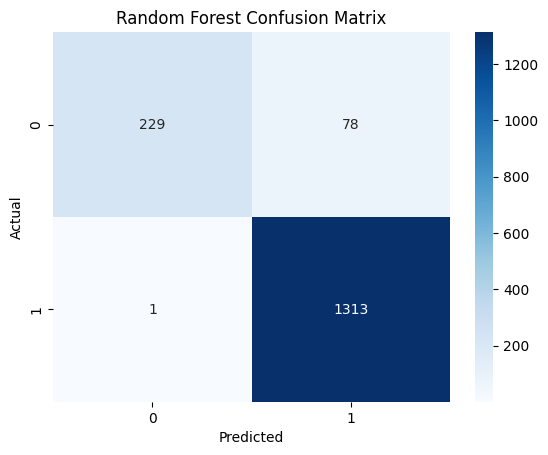

In [ ]:
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, cmap='Blues', fmt='d')
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# XGBoost

In [ ]:
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_model.fit(x_train, y_train)

y_pred_xgb = xgb_model.predict(x_test)

print("XGBoost Classifier Results:")
print(classification_report(y_test, y_pred_xgb))

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [01:03:18] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBoost Classifier Results:
              precision    recall  f1-score   support

           0       0.99      0.93      0.96       307
           1       0.98      1.00      0.99      1314

    accuracy                           0.98      1621
   macro avg       0.99      0.96      0.97      1621
weighted avg       0.98      0.98      0.98      1621



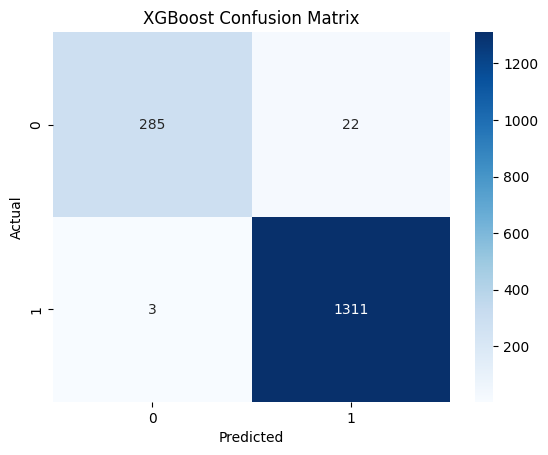

In [ ]:
sns.heatmap(confusion_matrix(y_test, y_pred_xgb), annot=True, cmap='Blues', fmt='d')
plt.title('XGBoost Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Bagging Classifier

In [ ]:
bagging_model = BaggingClassifier(estimator=DecisionTreeClassifier(),n_estimators=100,random_state=42)

bagging_model.fit(x_train, y_train)
y_pred_bagging = bagging_model.predict(x_test)

print("Bagging Classifier Results:")
print(classification_report(y_test, y_pred_bagging))

Bagging Classifier Results:
              precision    recall  f1-score   support

           0       0.97      0.93      0.95       307
           1       0.98      0.99      0.99      1314

    accuracy                           0.98      1621
   macro avg       0.98      0.96      0.97      1621
weighted avg       0.98      0.98      0.98      1621



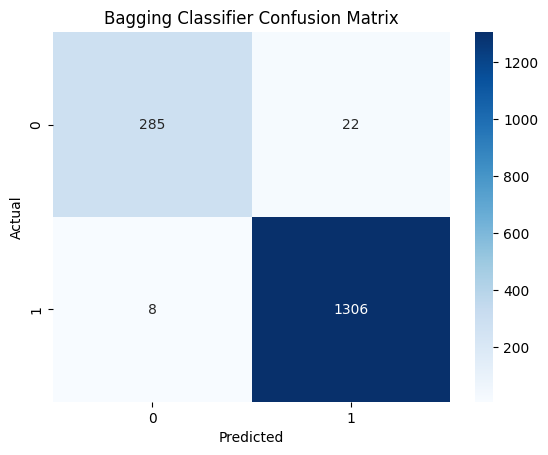

In [ ]:
sns.heatmap(confusion_matrix(y_test, y_pred_bagging), annot=True, cmap='Blues', fmt='d')
plt.title('Bagging Classifier Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Gradient Boosting

In [ ]:
gb_model = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb_model.fit(x_train, y_train)

y_pred_gb = gb_model.predict(x_test)

print("Gradient Boosting Classifier Results:")
print(classification_report(y_test, y_pred_gb))

Gradient Boosting Classifier Results:
              precision    recall  f1-score   support

           0       0.99      0.66      0.79       307
           1       0.93      1.00      0.96      1314

    accuracy                           0.93      1621
   macro avg       0.96      0.83      0.88      1621
weighted avg       0.94      0.93      0.93      1621



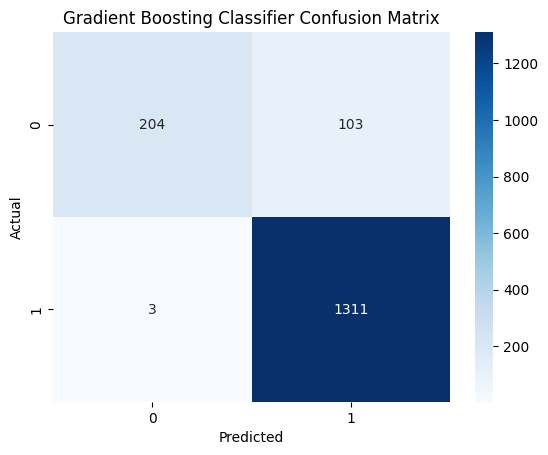

In [ ]:
sns.heatmap(confusion_matrix(y_test, y_pred_gb), annot=True, cmap='Blues', fmt='d')
plt.title('Gradient Boosting Classifier Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

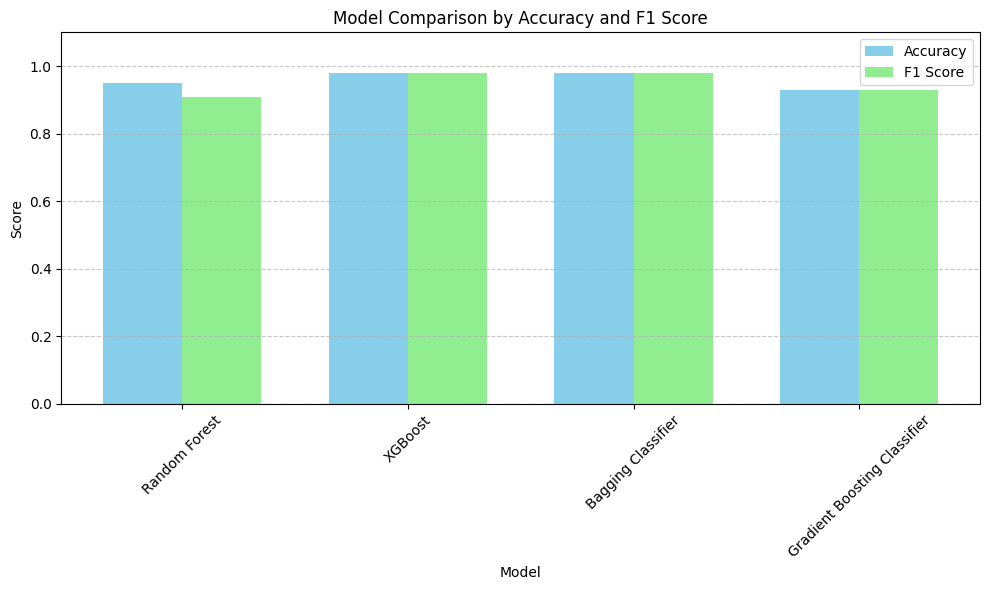

In [2]:
import matplotlib.pyplot as plt
import numpy as np

models = ['Random Forest', 'XGBoost', 'Bagging Classifier', 'Gradient Boosting Classifier']
accuracy = [0.95, 0.98, 0.98, 0.93]
f1_score = [0.91, 0.98, 0.98, 0.93]

# Bar width and positions
x = np.arange(len(models))
bar_width = 0.35

# Plotting
plt.figure(figsize=(10, 6))
plt.bar(x - bar_width/2, accuracy, width=bar_width, label='Accuracy',color='skyblue')
plt.bar(x + bar_width/2, f1_score, width=bar_width, label='F1 Score', color='lightgreen')

# Formatting
plt.xlabel('Model')
plt.ylabel('Score')
plt.title('Model Comparison by Accuracy and F1 Score')
plt.xticks(x, models, rotation=45)
plt.ylim(0, 1.1)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()